In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [2]:
pred_500 = pd.read_csv("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/predicted_k562_regulator_knockout_agarwal.csv")

In [3]:
pred_500['allele'] = pred_500['motif_name'].str.extract(r"_(ref|alt)")
pred_500['motif_group'] = pred_500['motif_name'].str.replace(r'_alt$', '', regex=True)
merged_df_ref = pred_500[pred_500['allele'] != 'alt'].copy()
merged_df_alt = pred_500[pred_500['allele'] == 'alt'].copy()


merged_df_ref = merged_df_ref.rename(columns={col: f"ref_{col}" for col in merged_df_ref.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
merged_df_alt = merged_df_alt.rename(columns={col: f"alt_{col}" for col in merged_df_alt.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

merged_df = pd.merge(merged_df_ref, merged_df_alt, on=['seq_id', 'motif_group'], how='inner')

offsets=range(-80,81)

# Compute diff_offset for each offset
for offset in offsets:
    merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']

avg_diff = merged_df.groupby('motif_group')[[f'diff_{offset}' for offset in offsets]].mean().reset_index()


/tmp/ipykernel_1508086/3955159958.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']
/tmp/ipykernel_1508086/3955159958.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']
/tmp/ipykernel_1508086/3955159958.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert`

In [4]:
# Update column names based on the value after diff_
updated_columns = []

for col in avg_diff.columns:
    if col.startswith("diff_"):  # Check if the column name starts with "diff_"
        value = int(col.split("_")[1])  # Extract the value after diff_
        if value < 0:
            updated_columns.append(f"{-value}")  # Append "right" for negative values
        elif value > 0:
            updated_columns.append(f"{-value}")  # Append "left" for positive values
        else:
            updated_columns.append(f"0")  # Append "center" for zero values
    else:
        updated_columns.append(col)  # Keep the motif_group column unchanged

# Assign the new column names back to the DataFrame
avg_diff.columns = updated_columns

# Print the updated column names to check
print(avg_diff.columns)


Index(['motif_group', '80', '79', '78', '77', '76', '75', '74', '73', '72',
       ...
       '-71', '-72', '-73', '-74', '-75', '-76', '-77', '-78', '-79', '-80'],
      dtype='object', length=162)


In [5]:
import re

def extract_number(col):
    match = re.search(r'(-?\d+)', col)
    return int(match.group(1)) if match else float('inf')

new_column_order = sorted(avg_diff.columns, key=extract_number)
avg_diff = avg_diff[new_column_order]


In [6]:
avg_diff

,-80,-79,-78,-77,-76,-75,-74,-73,-72,-71,...,72,73,74,75,76,77,78,79,80,motif_group
0,-0.032351,-0.033245,-0.034323,-0.034774,-0.034837,-0.035154,-0.036210,-0.036204,-0.036451,-0.037684,...,-0.061545,-0.062029,-0.062887,-0.061643,-0.061473,-0.062099,-0.059353,-0.059618,-0.058942,Arid3a_MA0151.1
1,0.132567,0.132297,0.132277,0.128141,0.129105,0.130849,0.130388,0.125551,0.127733,0.124629,...,0.161239,0.154649,0.150094,0.154976,0.146264,0.149118,0.147019,0.144050,0.144855,CTCFL_HUMAN.H11MO.0.A
2,0.045927,0.045341,0.045272,0.041701,0.039914,0.040424,0.038596,0.036928,0.035637,0.034550,...,0.033109,0.034486,0.034184,0.035948,0.034618,0.034339,0.038018,0.033752,0.039129,EGR1_C2H2_1
3,0.056875,0.058541,0.059362,0.057891,0.058500,0.060485,0.061693,0.057872,0.058846,0.058308,...,0.068364,0.066349,0.062821,0.063155,0.056983,0.053628,0.059299,0.051242,0.064092,EGR1_HUMAN.H11MO.0.A
4,0.048698,0.048095,0.044978,0.041730,0.040066,0.038798,0.033332,0.032555,0.033197,0.030756,...,0.000481,0.005853,0.005538,0.011654,0.011995,0.014204,0.018881,0.020877,0.031294,EWSR1-FLI1_MA0149.1
5,-0.014830,-0.016177,-0.018193,-0.019534,-0.021375,-0.022673,-0.025480,-0.028394,-0.031076,-0.033931,...,-0.099366,-0.099193,-0.100801,-0.094102,-0.094300,-0.092690,-0.091044,-0.089172,-0.085807,FOXC1_forkhead_1
6,0.000529,-0.000480,-0.001986,-0.006322,-0.007202,-0.008086,-0.010394,-0.013791,-0.014968,-0.016637,...,-0.065507,-0.067347,-0.065652,-0.062624,-0.063911,-0.061570,-0.059109,-0.059766,-0.056458,FOXO1_forkhead_2
7,-0.006706,-0.007946,-0.009329,-0.009798,-0.010979,-0.011392,-0.013083,-0.013710,-0.015412,-0.017769,...,-0.063779,-0.065483,-0.067764,-0.063693,-0.062559,-0.062524,-0.060414,-0.060234,-0.056281,FOXO1_forkhead_3
8,0.181915,0.181925,0.179851,0.177738,0.174375,0.174277,0.168514,0.169157,0.169982,0.166331,...,0.199946,0.205339,0.208302,0.209694,0.210815,0.215002,0.223889,0.223172,0.231987,GATA1+TAL1_MA0140.2
9,0.005282,0.004998,0.005381,0.004934,0.004933,0.004545,0.004426,0.004450,0.004387,0.003790,...,0.022945,0.022330,0.023789,0.025194,0.025769,0.024548,0.026190,0.024567,0.027662,IKZF1_HUMAN.H11MO.0.C


Index(['-80', '-79', '-78', '-77', '-76', '-75', '-74', '-73', '-72', '-71',
       ...
       '71', '72', '73', '74', '75', '76', '77', '78', '79', '80'],
      dtype='object', length=161)
range(0, 161)


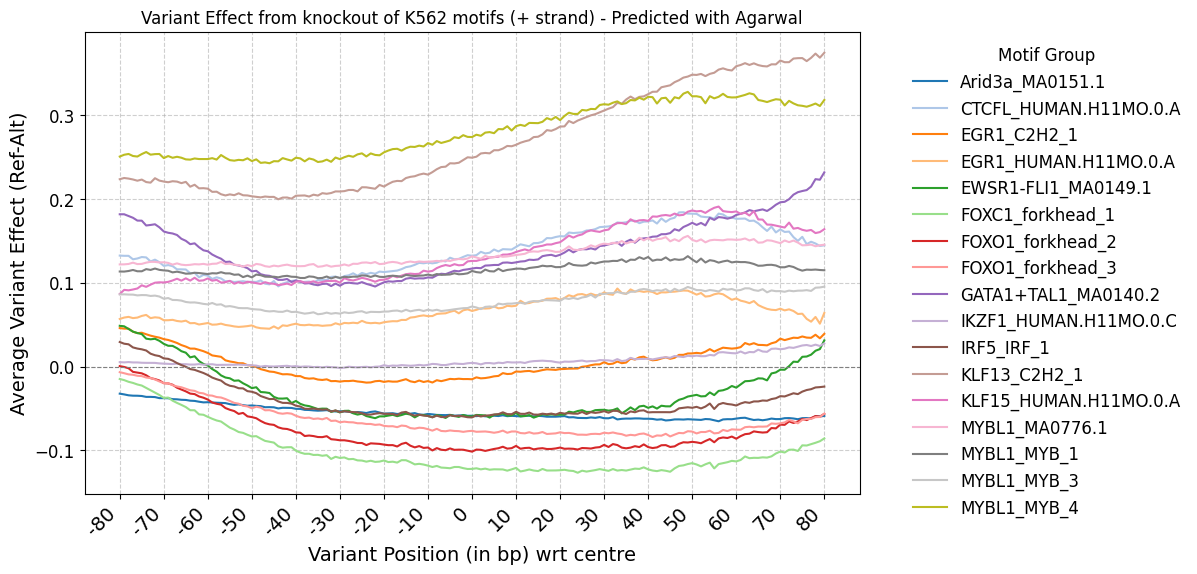

In [7]:
# Filter out Mouse-related motif groups
avg_diff = avg_diff[~avg_diff['motif_group'].str.contains("Mouse", case=False, na=False)]

offsets = range(-80,81)
mapped_offsets = offsets  # No transformation applied

# Generate distinct colors
num_motifs = avg_diff.shape[0]
colormap = plt.get_cmap("tab20")  # Use plt.get_cmap instead of cm.get_cmap
colors = [colormap(i % 20) for i in range(num_motifs)]  # Ensure we don't exceed 20 colors

# Plot
plt.figure(figsize=(10, 6))

x_labels = avg_diff.columns[:-1]  # Skip 'motif_group'
x_vals = range(len(x_labels))    # Use their index positions for plotting
print(x_labels)
print(x_vals)

for idx, (_, row) in enumerate(avg_diff.iterrows()):
    y_vals = row[:-1]  
    plt.plot(x_vals, y_vals, label=row['motif_group'], color=colors[idx])

# Formatting
plt.xlabel("Variant Position (in bp) wrt centre",  fontsize=14)
plt.ylabel("Average Variant Effect (Ref-Alt)",  fontsize=14)
tick_indices = list(range(0, len(x_labels), 10))
tick_labels = [x_labels[i] for i in tick_indices]
plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=45, ha="right", fontsize=14)

# plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # Add horizontal reference line
plt.legend(title="Motif Group", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False,  fontsize=12, title_fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.title("Variant Effect from knockout of K562 motifs (+ strand) - Predicted with Agarwal")
plt.savefig("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/knockout_agarwal.svg", format="svg")

# Show plot
plt.show()
